In [29]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
config = {
    "sigma_pos": 10.0,
    "sigma_vel": 1.0,
    "sigma_init": 10.0,
    "e_v": 5.0,         
    "q": 1.0,          
    "N_particles": 15000
}

In [31]:
def generate_ground_truth(T=500, dt=0.01):
    t = np.arange(0, T, dt)
    v0 = 50.0        # m/s
    ax = 0.2        # m/s^2
    A = 100.0        # amplitude lateral
    omega = 0.05     # rad/s

    x = v0*t + 0.5*ax*t**2
    y = A*np.sin(omega*t)

    vx = np.gradient(x,dt)
    vy = np.gradient(y,dt)

    return t, x, y, vx, vy

t, x, y, vx, vy = generate_ground_truth()

In [32]:
def radar_measurements_fusion(t_truth, x, y, vx, vy, sigma_pos, sigma_vel, rate = 1.0):
    dt_meas = 1 / rate
    t_meas = np.arange(0, t_truth[-1], dt_meas)

    x_meas = np.interp(t_meas, t_truth, x)
    y_meas = np.interp(t_meas, t_truth, y)
    vx_meas = np.interp(t_meas, t_truth, vx)
    vy_meas = np.interp(t_meas, t_truth, vy)

    noise_pos = np.random.randn(len(t_meas), 2) * sigma_pos
    noise_vel = np.random.randn(len(t_meas), 2) * sigma_vel

    z = np.column_stack((x_meas, y_meas, vx_meas, vy_meas))
    z[:, :2] += noise_pos
    z[:, 2:] += noise_vel

    return t_meas, z

t_meas, z = radar_measurements_fusion(t, x, y, vx, vy, config["sigma_pos"], config["sigma_vel"])

In [33]:
def apply_missing_data(z, missing_prob = 0.1):
    mask = np.random.rand(len(z))> missing_prob
    z_missing = z.copy()
    z_missing[~mask]=np.nan

    return z_missing, mask

z_missing, mask = apply_missing_data(z)

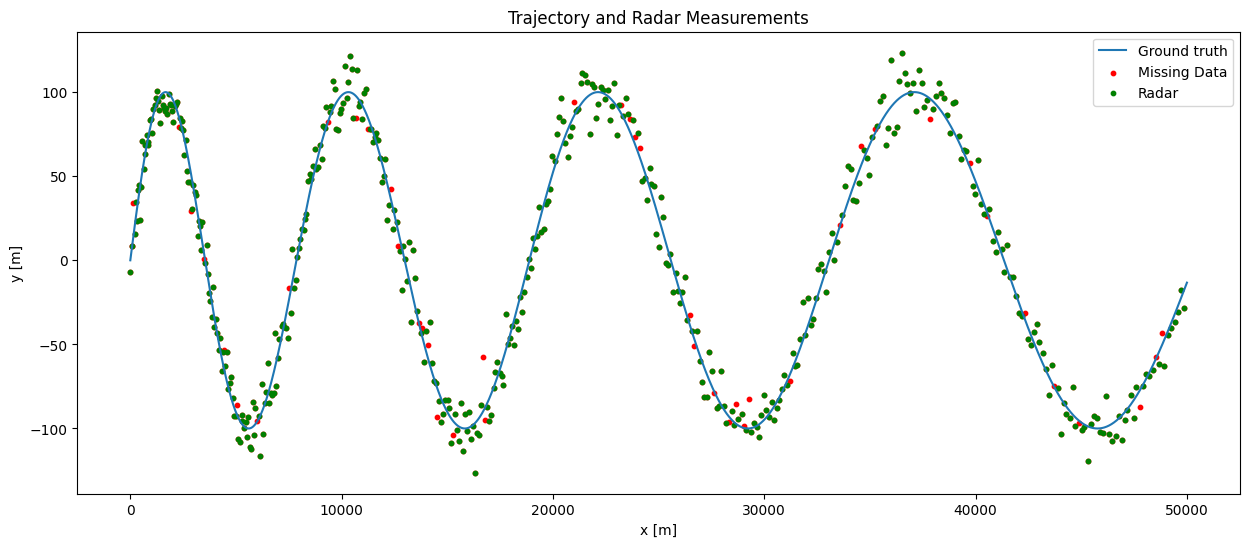

In [34]:
plt.figure(figsize = (15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(z[:,0], z[:,1], s = 10, label = "Missing Data", color = "red")
plt.scatter(z_missing[:,0], z_missing[:,1], s = 10, label = "Radar", color = "green")
plt.legend()
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Trajectory and Radar Measurements")
plt.show()

In [35]:
def init_kalman(z, config):

    sigma_pos = config["sigma_pos"]
    sigma_vel = config["sigma_vel"]
    
    x0 = np.array([z[0, 0], z[0, 1], z[0, 2], z[0,2]]).reshape(-1, 1)
    P0 = np.eye(4) * 1e6
    
    H = np.eye(4)
    
    R = np.diag([sigma_pos**2, sigma_pos**2, sigma_vel**2, sigma_vel**2])

    return x0, P0, H, R

In [36]:
def run_kalman_filter(t_meas, z_missing, x_hat, P, H, R, q) :

    x_estimates = []
    x_estimates.append(x_hat.copy())
    
    for k in range(1, len(t_meas)) :
    
        dt = t_meas[k] - t_meas[k-1]
    
        F = np.array([
            [1, 0, dt, 0],
            [0, 1, 0, dt],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])
        
        Q = q * np.array([
            [dt**4/4, 0, dt**3/2, 0],
            [0, dt**4/4, 0, dt**3/2],
            [dt**3/2, 0, dt**2, 0],
            [0, dt**3/2, 0, dt**2]
        ])
    
        x_hat = F @ x_hat
        P = F @ P @ F.T + Q
    
        z_k = z_missing[k]

        if not np.isnan(z_k).any() :
            z_k = z_k.reshape((4,1))
            y_k = z_k - H @ x_hat
            S = H @ P @ H.T + R
            K = P @ H.T @ np.linalg.inv(S)
            x_hat = x_hat + K @ y_k
            P = (np.eye(4) - K @ H) @ P
            
        x_estimates.append(x_hat.copy())
    return np.array(x_estimates)

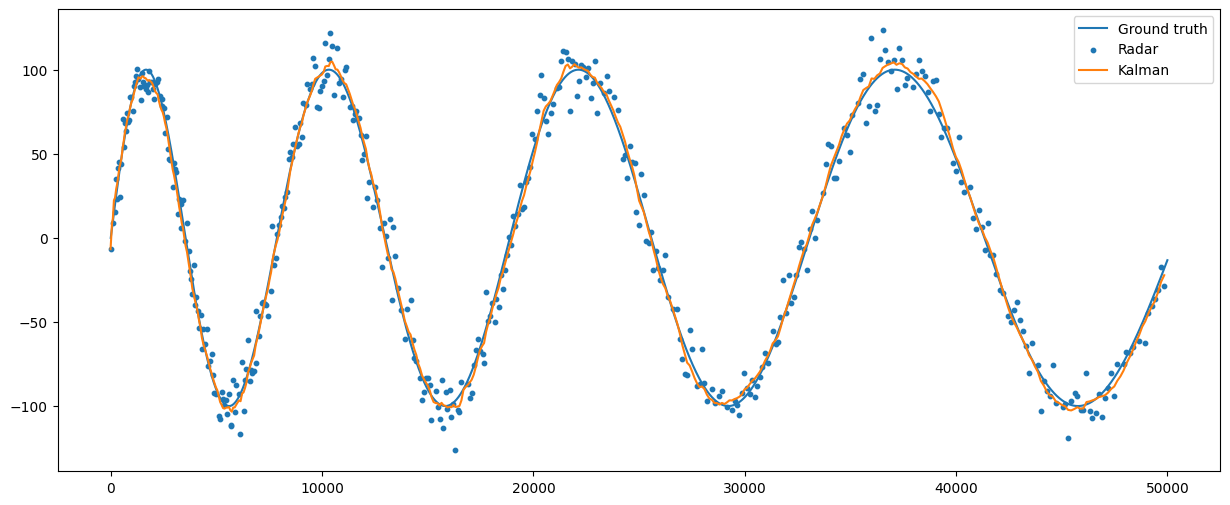

In [37]:
x0, P0, H, R = init_kalman(z, config)
x_kalman = run_kalman_filter(t_meas, z, x0, P0, H, R, config["q"]).squeeze()

plt.figure(figsize = (15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(z_missing[:,0], z_missing[:,1], s= 10, label = "Radar")
plt.plot(x_kalman[:,0], x_kalman[:,1], label = "Kalman")
plt.legend()
plt.show()

In [38]:
def init_particles(z, config):
    
    N = config["N_particles"]
    e_v = config["e_v"]
    sigma_init = config["sigma_init"]
    
    particles = np.zeros((N, 4))
    
    particles[:, 0] = z[0, 0] + np.random.randn(N) * sigma_init
    particles[:, 1] = z[0, 1] + np.random.randn(N) * sigma_init
    particles[:, 2] = z[0, 2] + np.random.randn(N) * e_v
    particles[:, 3] = z[0, 3] + np.random.randn(N) * e_v
    
    weights = np.ones(N) / N

    return particles, weights

In [39]:
def predict_particles(particles, dt, q) :
    N = particles.shape[0]

    noise_pos = np.random.randn(N, 2) * np.sqrt(q) * dt**2 / 2
    noise_vel = np.random.randn(N, 2) * np.sqrt(q) * dt

    particles[:, 0] += particles[:, 2] * dt + noise_pos[:, 0]
    particles[:, 1] += particles[:, 3] * dt + noise_pos[:, 1]
    particles[:, 2] += noise_vel[:, 0]
    particles[:, 3] += noise_vel[:, 1]

    return particles

In [40]:
def update_weights(particles, weights, z, sigma_pos, sigma_vel) :
    diffs = particles - z.reshape(1, 4)
    
    d2_pos = np.sum(diffs[:, :2]**2, axis = 1)
    d2_vel = np.sum(diffs[:, 2:]**2, axis = 1)

    log_w = -0.5 * (d2_pos / sigma_pos**2 + d2_vel / sigma_vel**2)
    log_w -= np.max(log_w)
    
    weights = np.exp(log_w)
    weights /= np.sum(weights)

    if np.sum(weights) == 0 or np.isnan(weights).any():
        weights.fill(1.0 / len(weights))

    return weights

In [41]:
def N_eff(weights) :
    return 1. / np.sum(weights**2)

In [42]:
def resample(particles, weights) :
    N = len(weights)
    positions = (np.arange(N) + np.random.rand()) / N

    indexes = np.zeros(N, dtype = int)
    cumulative_sum = np.cumsum(weights)
    i, j = 0, 0

    while i < N :
        if positions[i] < cumulative_sum[j] :
            indexes[i] = j
            i += 1  
        else :
            j += 1

    particles[:] = particles[indexes]
    weights.fill(1 / N)

    return particles, weights

In [43]:
def estimate(particles, weights) :
    return np.average(particles, weights = weights, axis = 0)

In [44]:
def run_particle_filter(t_meas, z_missing, particles, weights, q, sigma_pos, sigma_vel) :

    estimates = []
    x_est0 = np.average(particles, weights=weights, axis=0)
    estimates.append(x_est0.copy())
    
    for k in range(1, len(t_meas)) :
        dt = t_meas[k] - t_meas[k-1]
    
        particles = predict_particles(particles, dt, q)
    
        if not np.isnan(z.any()) :
            weights = update_weights(particles, weights, z[k], config["sigma_pos"], config["sigma_vel"])
    
            if N_eff(weights) < config["N_particles"] * 0.5 :
                particles, weights = resample(particles, weights)
    
        x_hat = estimate(particles, weights)
        estimates.append(x_hat.copy())
    return np.array(estimates)

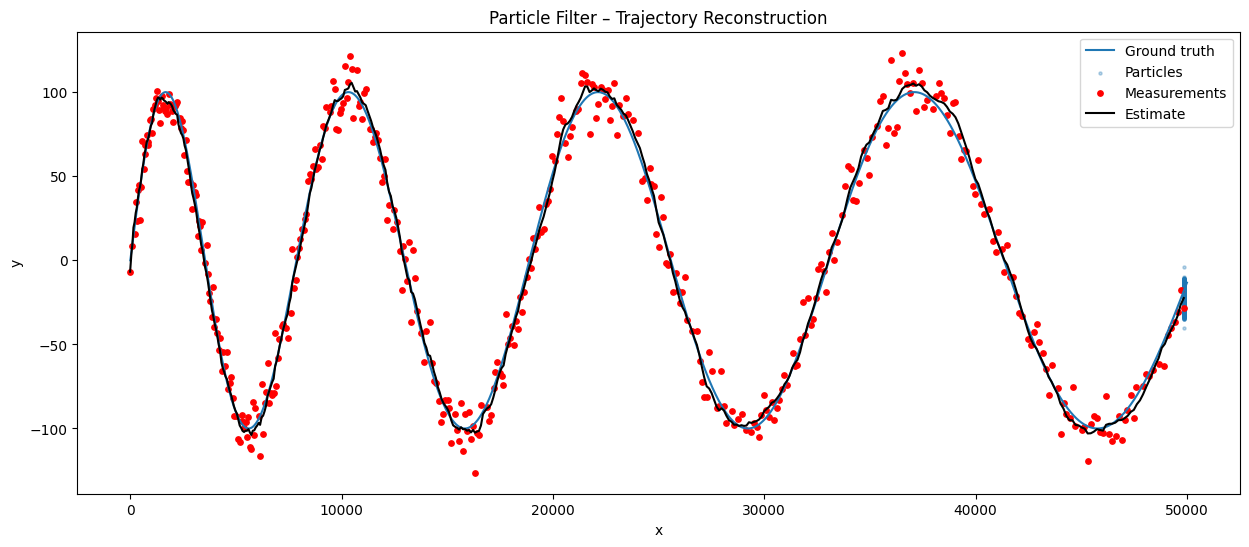

In [45]:
particles, weights = init_particles(z, config)
x_pf = run_particle_filter(t_meas, z, particles, weights, config["q"], config["sigma_pos"], config["sigma_vel"])

plt.figure(figsize=(15, 6))
plt.plot(x, y, label = "Ground truth")
plt.scatter(particles[:, 0], particles[:, 1], s = 5, alpha = 0.3, label = "Particles")
plt.scatter(z_missing[:, 0], z_missing[:, 1], c = "red", s = 15, label = "Measurements")
plt.plot(x_pf[:, 0], x_pf[:, 1], c = "black", label = "Estimate")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Particle Filter – Trajectory Reconstruction")
plt.show()

In [46]:
def rms_position(x_est, x_true) :
    error_pos = x_est[:, :2] - x_true[:, :2]
    return np.sqrt(np.mean(np.sum(error_pos**2, axis = 1)))

In [47]:
def rms_velocity( x_est, x_true) :
    error_vel = x_est[:, 2:] - x_true[:, 2:]
    return np.sqrt(np.mean(np.sum(error_vel**2, axis = 1)))

In [48]:
x_true = np.column_stack((
    np.interp(t_meas, t, x),
    np.interp(t_meas, t, y),
    np.interp(t_meas, t, vx),
    np.interp(t_meas, t, vy)
))

In [49]:
rms_kalman_pos = rms_position(x_kalman, x_true)
rms_pf_pos = rms_position(x_pf, x_true)

print("RMS Kalman: ", rms_kalman_pos)
print("RMS Particle Filter: ", rms_pf_pos)

RMS Kalman:  4.60767011539946
RMS Particle Filter:  4.840206110969913


In [50]:
rms_kalman_vel = rms_velocity(x_kalman, x_true)
rms_pf_vel = rms_velocity(x_pf, x_true)

print("RMS Kalman: ", rms_kalman_vel)
print("RMS Particle Filter: ", rms_pf_vel)

RMS Kalman:  2.2037523310342246
RMS Particle Filter:  0.9622847373436125


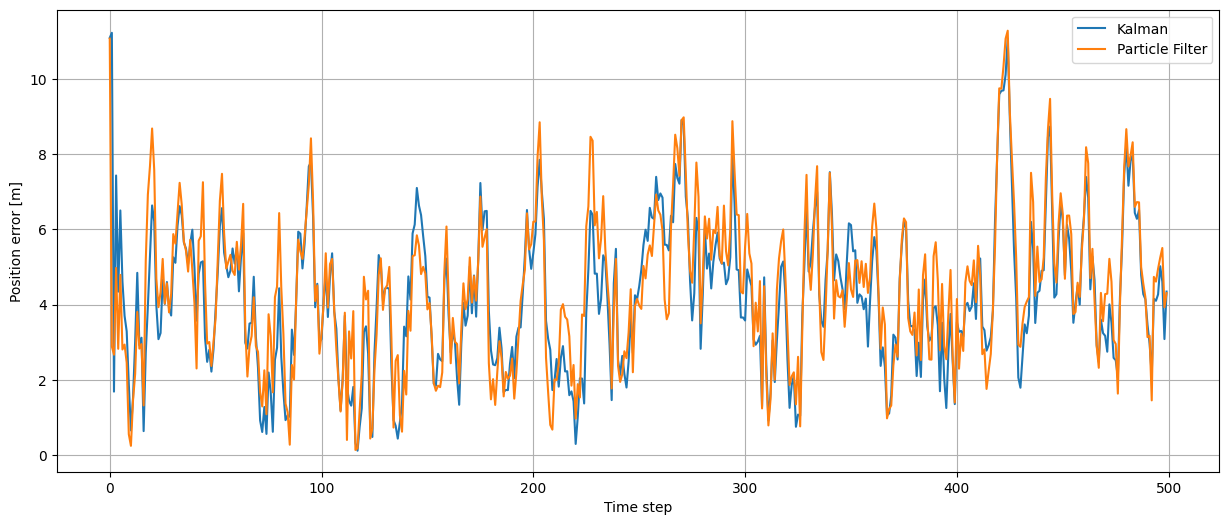

In [51]:
error_kalman = np.linalg.norm(x_kalman[:, :2] - x_true[:, :2], axis = 1)
error_pf = np.linalg.norm(x_pf[:, :2] - x_true[:, :2], axis = 1)

plt.figure(figsize = (15, 6))
plt.plot(error_kalman, label = "Kalman")
plt.plot(error_pf, label = "Particle Filter")
plt.xlabel("Time step")
plt.ylabel("Position error [m]")
plt.legend()
plt.grid()
plt.show()

In [52]:
sigma_values = [5, 10, 20, 50, 100, 200, 500, 1000, 1500]
sigma_vel = []

rms_kalman_list_p = []
rms_pf_list_p = []
rms_kalman_list_v = []
rms_pf_list_v = []

for sigma_p in sigma_values :
    config["sigma_pos"] = sigma_p
    config["sigma_vel"] = sigma_p / 10
    
    sigma_vel.append(sigma_p / 10)
    
    t_meas, z = radar_measurements_fusion(t, x, y, vx, vy, config["sigma_pos"], config["sigma_vel"], rate = 1)

    x0, P0, H, R = init_kalman(z, config)
    x_kalman_estimates = run_kalman_filter(t_meas, z, x0, P0, H, R, config["q"]).squeeze()

    particles, weights = init_particles(z, config)
    x_pf_estimates = run_particle_filter(t_meas, z, particles, weights, config["q"], config["sigma_pos"], config["sigma_vel"])

    rms_kalman_list_p.append(rms_position(x_kalman_estimates, x_true))
    rms_pf_list_p.append(rms_position(x_pf_estimates, x_true))
    rms_kalman_list_v.append(rms_velocity(x_kalman_estimates, x_true))
    rms_pf_list_v.append(rms_velocity(x_pf_estimates, x_true))

config["sigma_pos"] = 10
config["sigma_vel"] = 1

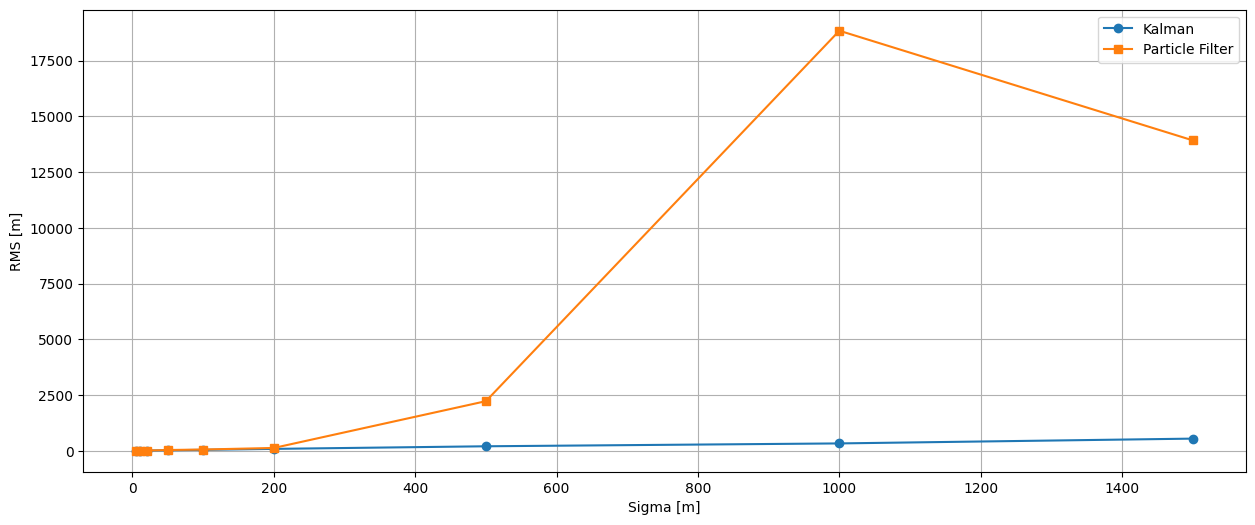

In [53]:
plt.figure(figsize = (15, 6))
plt.plot(sigma_values, rms_kalman_list_p, 'o-', label = 'Kalman')
plt.plot(sigma_values, rms_pf_list_p, 's-', label = 'Particle Filter')
plt.xlabel('Sigma [m]')
plt.ylabel('RMS [m]')
plt.legend()
plt.grid(True)
plt.show()

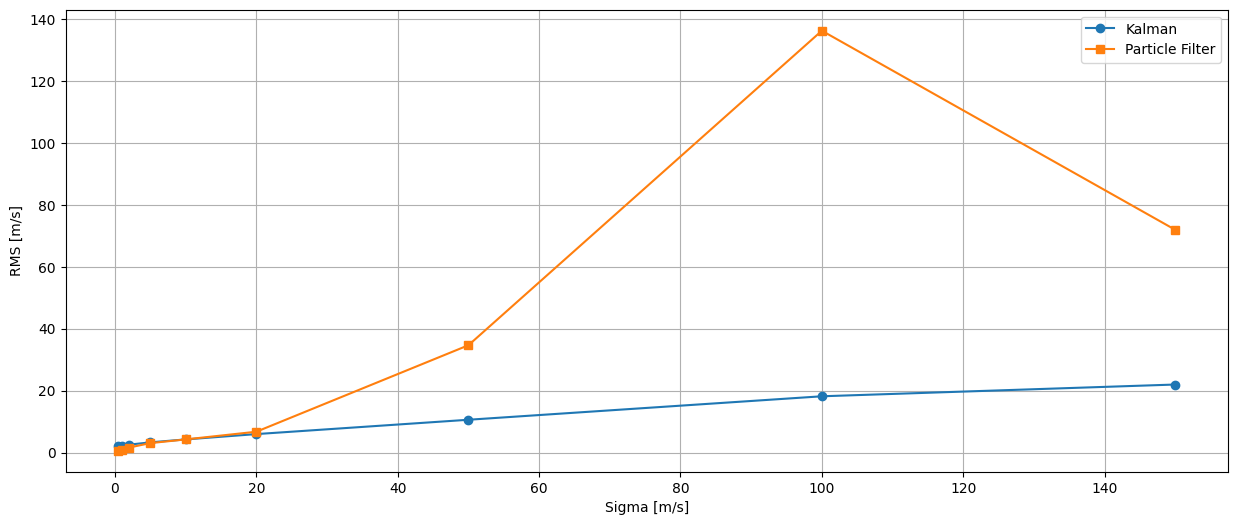

In [54]:
plt.figure(figsize = (15, 6))
plt.plot(sigma_vel, rms_kalman_list_v, 'o-', label = 'Kalman')
plt.plot(sigma_vel, rms_pf_list_v, 's-', label = 'Particle Filter')
plt.xlabel('Sigma [m/s]')
plt.ylabel('RMS [m/s]')
plt.legend()
plt.grid(True)
plt.show()

In [55]:
def radar_measurements_outliers(t_truth, x, y, vx, vy, sigma_pos, sigma_vel , rate = 1, p_outlier = 0.1, outlier_scale_p = 10, outlier_scale_v = 3):
    dt_meas = 1/rate
    t_meas = np.arange(0, t_truth[-1], dt_meas)

    x_meas = np.interp(t_meas, t_truth, x)
    y_meas = np.interp(t_meas, t_truth, y)
    vx_meas = np.interp(t_meas, t_truth, vx)
    vy_meas = np.interp(t_meas, t_truth, vy)

    noise_pos = np.random.randn(len(t_meas), 2) * sigma_pos
    noise_vel = np.random.randn(len(t_meas), 2) * sigma_vel

    noise = np.column_stack((noise_pos, noise_vel))

    outliers = np.random.rand(len(t_meas)) < p_outlier
    noise[outliers, :2] += np.random.randn(np.sum(outliers), 2) * sigma_pos * outlier_scale_p
    noise[outliers, 2:] += np.random.randn(np.sum(outliers), 2) * sigma_vel * outlier_scale_v
    
    z = np.column_stack((x_meas, y_meas, vx_meas, vy_meas)) + noise
    return t_meas, z

t_meas, z = radar_measurements_outliers(t, x, y, vx, vy, config["sigma_pos"], config["sigma_vel"])

In [56]:
x0, P0, H, R = init_kalman(z, config)
x_kalman = run_kalman_filter(t_meas, z, x0, P0, H, R, config["q"]).squeeze()

particles, weights = init_particles(z, config)
x_pf = run_particle_filter(t_meas, z, particles, weights, config["q"], config["sigma_pos"], config["sigma_vel"])

In [57]:
rms_kalman = rms_position(x_kalman, x_true)
rms_pf = rms_position(x_pf, x_true)

print("RMS Kalman: ", rms_kalman)
print("RMS Particle Filter: ", rms_pf)

RMS Kalman:  9.60597503222519
RMS Particle Filter:  8.294277407300791


In [58]:
rms_kalman_vel = rms_velocity(x_kalman, x_true)
rms_pf_vel = rms_velocity(x_pf, x_true)

print("RMS Kalman: ", rms_kalman_vel)
print("RMS Particle Filter: ", rms_pf_vel)

RMS Kalman:  2.409057570646625
RMS Particle Filter:  1.279208379116148


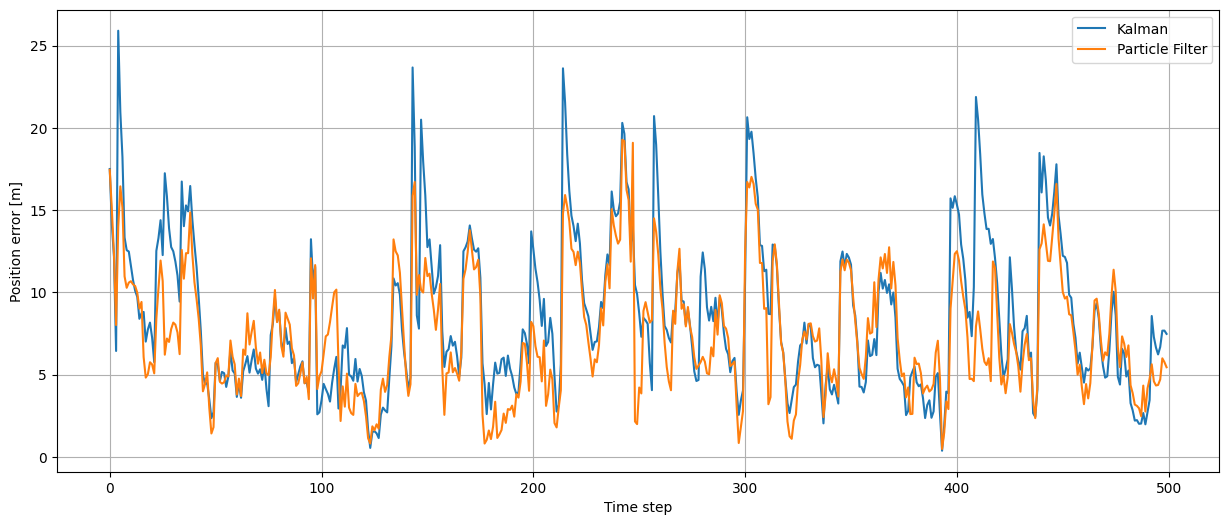

In [59]:
error_kalman = np.linalg.norm(x_kalman[:, :2] - x_true[:, :2], axis = 1)
error_pf = np.linalg.norm(x_pf[:, :2] - x_true[:, :2], axis = 1)

plt.figure(figsize = (15, 6))
plt.plot(error_kalman, label = "Kalman")
plt.plot(error_pf, label = "Particle Filter")
plt.xlabel("Time step")
plt.ylabel("Position error [m]")
plt.legend()
plt.grid()
plt.show()

In [60]:
sigma_values = [5, 10, 20, 50, 100, 200, 500, 1000, 1500]

rms_kalman_list_p = []
rms_pf_list_p = []
rms_kalman_list_v = []
rms_pf_list_v = []

for sigma_p in sigma_values :
    config["sigma_pos"] = sigma_p
    config["sigma_vel"] = sigma_p / 10
    
    t_meas, z = radar_measurements_outliers(t, x, y, vx, vy, config["sigma_pos"], config["sigma_vel"])

    x0, P0, H, R = init_kalman(z, config)
    x_kalman_estimates = run_kalman_filter(t_meas, z, x0, P0, H, R, config["q"]).squeeze()

    particles, weights = init_particles(z, config)
    x_pf_estimates = run_particle_filter(t_meas, z, particles, weights, config["q"], config["sigma_pos"], config["sigma_vel"])

    rms_kalman_list_p.append(rms_position(x_kalman_estimates, x_true))
    rms_pf_list_p.append(rms_position(x_pf_estimates, x_true))
    rms_kalman_list_v.append(rms_velocity(x_kalman_estimates, x_true))
    rms_pf_list_v.append(rms_velocity(x_pf_estimates, x_true))

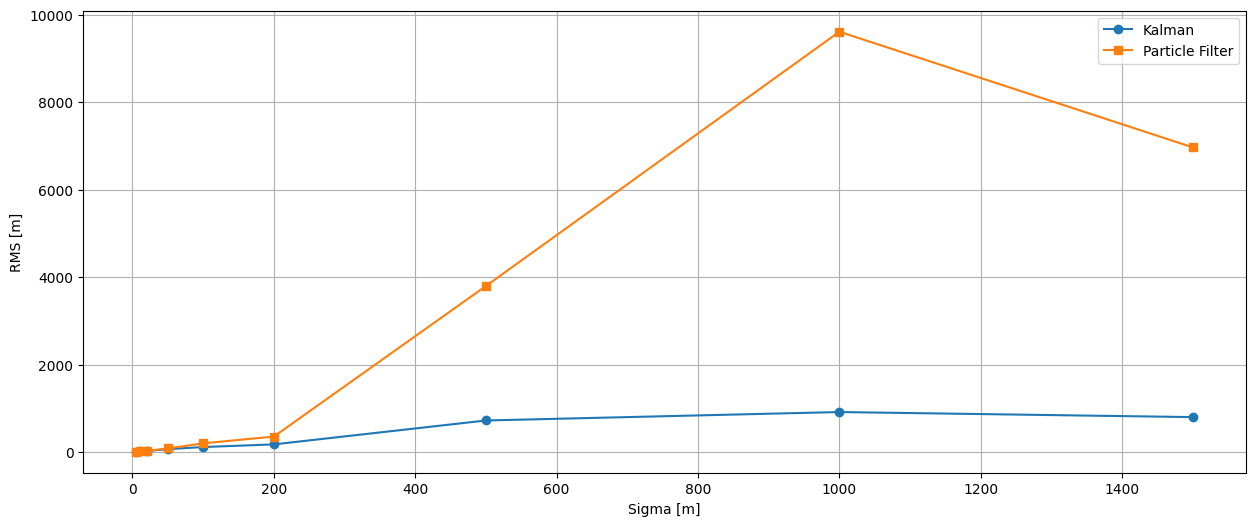

In [61]:
plt.figure(figsize = (15, 6))
plt.plot(sigma_values, rms_kalman_list_p, 'o-', label = 'Kalman')
plt.plot(sigma_values, rms_pf_list_p, 's-', label = 'Particle Filter')
plt.xlabel('Sigma [m]')
plt.ylabel('RMS [m]')
plt.legend()
plt.grid(True)
plt.show()

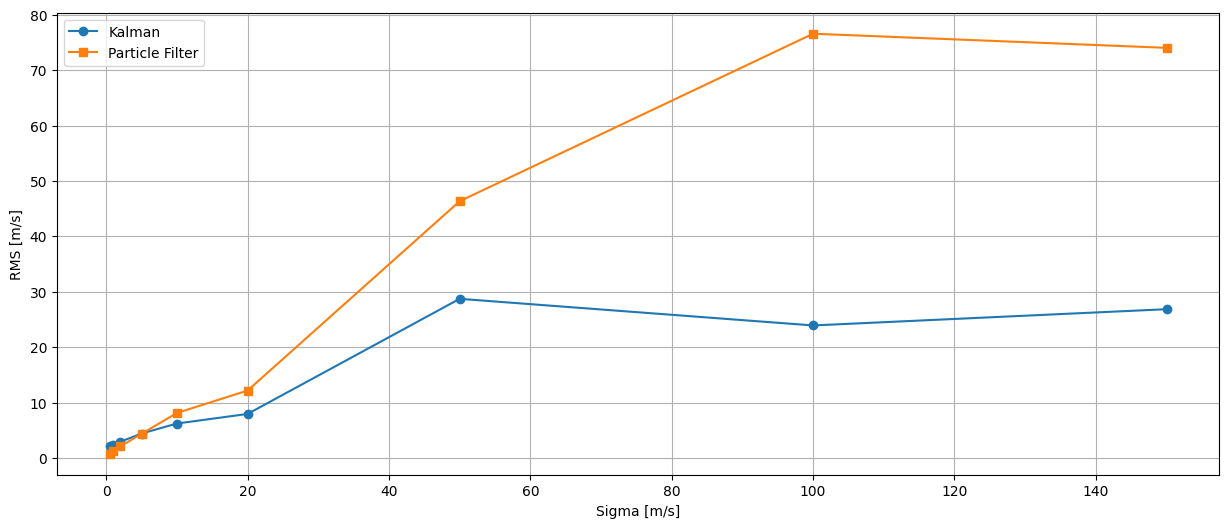

In [62]:
plt.figure(figsize = (15, 6))
plt.plot(sigma_vel, rms_kalman_list_v, 'o-', label = 'Kalman')
plt.plot(sigma_vel, rms_pf_list_v, 's-', label = 'Particle Filter')
plt.xlabel('Sigma [m/s]')
plt.ylabel('RMS [m/s]')
plt.legend()
plt.grid(True)
plt.show()